# Project 09: AI Drug–Target Interaction & Binding Affinity

## Core Research Question
> **Can AI learn relationships between molecular structure and protein sequence/structure to predict drug–target interaction and binding affinity?**

---

### Executive Overview & Scientific Motivation
In contemporary computer-aided drug discovery (CADD) and chemogenomics, identifying whether a small molecule binds to a specific macromolecular target—and quantifying its binding affinity ($K_i, K_d$)—is fundamental:
- **Lead Discovery & Polypharmacology**: Systematically mapping chemical space against proteome-wide targets to detect primary efficacy and off-target liabilities (e.g. hERG cardiotoxicity, CYP450 inhibition).
- **Target Deconvolution**: Identifying biological targets for phenotypic screening hits where the mechanism of action (MoA) is unknown.
- **Overcoming Docking Bottlenecks**: While 3D molecular docking requires high-resolution crystal structures (unavailable for many membrane receptors and disordered proteins), sequence-based deep learning operates directly on primary **amino acid sequences**.

### The Chemogenomic DTI Problem
A Drug–Target Interaction (DTI) model takes as input a pair:
$$(\mathbf{L}, \mathbf{P}) \quad \text{where } \mathbf{L} = \text{Small-Molecule Ligand}, \quad \mathbf{P} = \text{Macromolecular Protein Target}$$

And simultaneously predicts:
1. **Binary Interaction State**: $\hat{y} \in \{0, 1\}$ (Interaction vs Non-Interaction).
2. **Quantitative Continuous Affinity**: $pK_i = -\log_{10}(K_i \cdot 10^{-9}) \in \mathbb{R}$ ($4.0 - 11.0$).

```text
==================================================================================================
                 AI DRUG–TARGET INTERACTION & AFFINITY PIPELINE (DTI)
==================================================================================================

  Raw BindingDB Database (8.98 GB TSV: BindingDB_All_202609_tsv)
            │
            ▼
  [STAGE 1: Streaming Loader & Data Curation] ───> Memory-efficient chunked reader
            │                                     Extracts clean Ki records with full sequence
            ▼
  [STAGE 2: Endpoint Isolation & Cheng-Prusoff] -> Justifies Ki vs Kd vs IC50 thermodynamics
            │                                     Eliminates assay substrate confounders
            ▼
  [STAGE 3: Affinity Normalization (pKi)] ───────> pKi = 9 - log10(Ki_nM) (dynamic range: 4 - 11)
            │
            ▼
  [STAGE 4: Target & Sequence Normalization] ───> UniProt ID mapping & canonical sequence cleaning
            │                                     Validates amino acid alphabet (20 standard AA)
            ▼
  [STAGE 5: Multi-Scale Ligand Featurization] ──> ECFP4 Fingerprints + RDKit Phys-Chem Descriptors
            │
            ▼
  [STAGE 6: Protein Sequence Representation] ───> Conjoint Triad (CTD, 343D) + AAC (20D)
            │
            ▼
  [STAGE 7: Dual-Branch Deep Neural Network] ───> Ligand Tower (128D) + Protein Tower (128D)
            │                                     Bilinear Cross-Modal Fusion Block (512D)
            ▼
  [STAGE 8: Multi-Task Interaction Prediction] ──> Task 1: Continuous pKi Regression
            │                                     Task 2: Binary Interaction (pKi >= 7.0)
            ▼
  [STAGE 9: Multi-Regime Generalization Splits] -> 1. Random Split
            │                                     2. Cold-Drug Split (Unseen scaffolds)
            │                                     3. Cold-Target Split (Unseen proteins)
            ▼
  [STAGE 10: Epistemic Uncertainty Quantification] > Monte Carlo Dropout (30 stochastic passes)
            │                                       Predicted Mean Affinity ± 95% Confidence
            ▼
  Export Deliverables (bindingdb_curated_ki.csv, dti_predictions.csv, dti_model_metadata.json)
==================================================================================================
```


In [1]:
# =============================================================================
# ENVIRONMENT CONFIGURATION & SCIENTIFIC LIBRARIES IMPORT
# =============================================================================
import os
import sys
import csv
import json
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# RDKit Cheminformatics
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, QED, DataStructs
from rdkit.Chem import rdFingerprintGenerator

# Scikit-Learn Modeling & Validation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score
)
from scipy.stats import pearsonr, spearmanr

# Suppress minor warnings for clean output presentation
warnings.filterwarnings('ignore')

# Matplotlib & Seaborn Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Robust Directory Resolution
found_base = None
for candidate in [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.abspath(os.path.join(os.getcwd(), "Project -09 AI Drug–Target Interaction & Binding Affinity")),
    os.path.abspath(os.path.join(os.getcwd(), "Project -09 AI Drug-Target Interaction & Binding Affinity"))
]:
    if os.path.exists(os.path.join(candidate, "dataset", "bindingdb_curated_ki.csv")) or os.path.exists(os.path.join(candidate, "notebook")):
        found_base = candidate
        break

BASE_DIR = found_base if found_base else os.getcwd()
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Hardware Acceleration Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[OK] Python Version       : {sys.version.split()[0]}")
print(f"[OK] PyTorch Version      : {torch.__version__} (Device: {DEVICE})")
print(f"[OK] RDKit Version        : {rdkit.__version__}")
print(f"[OK] Base Directory       : {BASE_DIR}")
print(f"[OK] Dataset Directory    : {DATASET_DIR}")
print(f"[OK] Results Directory    : {RESULTS_DIR}")


[OK] Python Version       : 3.13.15
[OK] PyTorch Version      : 2.14.0+cpu (Device: cpu)
[OK] RDKit Version        : 2026.03.6
[OK] Base Directory       : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -09 AI Drug–Target Interaction & Binding Affinity
[OK] Dataset Directory    : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -09 AI Drug–Target Interaction & Binding Affinity\dataset
[OK] Results Directory    : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -09 AI Drug–Target Interaction & Binding Affinity\results


---
# Steps 1 & 2: Loading BindingDB & Homogeneous Endpoint Selection

### The Biophysical Trap: Why You Must Never Mix $K_i$, $K_d$, and $IC_{50}$ Blindly
In public databases like BindingDB and ChEMBL, binding data is reported across multiple biochemical metrics. Inexperienced practitioners often merge them into a single column, which introduces fatal thermodynamic noise into machine learning models:

1. **Inhibition Constant ($K_i$)**:
   The true thermodynamic equilibrium constant of the enzyme-inhibitor complex:
   $$E + I \rightleftharpoons EI, \quad K_i = \frac{[E][I]}{[EI]}$$
   $K_i$ reflects intrinsic molecular affinity and is **independent of substrate concentration $[S]$**.
2. **Dissociation Constant ($K_d$)**:
   The equilibrium dissociation constant measured directly via physical methods (e.g., Surface Plasmon Resonance, ITC). Under non-enzymatic equilibrium, $K_d \approx K_i$.
3. **Half-Maximal Inhibitory Concentration ($IC_{50}$)**:
   The functional concentration required to reduce enzymatic velocity by 50%. For competitive inhibition, $IC_{50}$ is governed by the **Cheng-Prusoff equation**:
   $$IC_{50} = K_i \left( 1 + \frac{[S]}{K_m} \right)$$
   Where $[S]$ is the experimental substrate concentration and $K_m$ is the Michaelis constant. Because $[S]/K_m$ varies between 0.1 and 10 across different laboratories, **two identical molecules tested in different assays can yield tenfold different $IC_{50}$ values despite identical $K_i$**!

### Our Curatorial Protocol: Strict $K_i$ Endpoint Isolation
To ensure strict thermodynamic consistency, we isolate **only unambiguous $K_i$ measurements**:
- Exclusion of relational qualifiers (`>`, `<`, `~`).
- Exclusion of multichain target complexes lacking single-chain sequence mapping.
- Requirement for verified **UniProt Primary Accessions** and complete amino acid sequences.


=== BINDINGDB CURATED BENCHMARK SUMMARY ===
Total Drug-Target Pairs : 10,000
Unique Small Molecules  : 5,983
Unique Protein Targets  : 255
Endpoint Selected       : Homogeneous Ki (Inhibition Constant)
Dynamic Ki Range        : 0.01 nM  to  100,000 nM

First 5 Curated Drug-Target Pairs:
compound_id                                                                                      smiles uniprot_id                            target_name target_family  ki_nM   pKi  seq_len
CMPD_000001         O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(CCCCCC(O)=O)C(=O)N(CCCCCC(O)=O)[C@@H]1Cc1ccccc1     P03367 Dimer of Gag-Pol polyprotein [501-599]  Other Target   0.24 9.620       99
CMPD_000002 O=C1N(C/C=C/c2cn[nH]c2)[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@H](Cc2ccccc2)N1C/C=C/c1cn[nH]c1     P03367 Dimer of Gag-Pol polyprotein [501-599]  Other Target   0.25 9.602       99
CMPD_000003           O=C1N(C/C=C/c2cn[nH]c2)[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@H](Cc2ccccc2)N1CC1CC1     P03367 Dimer of Gag-Pol polyprotei

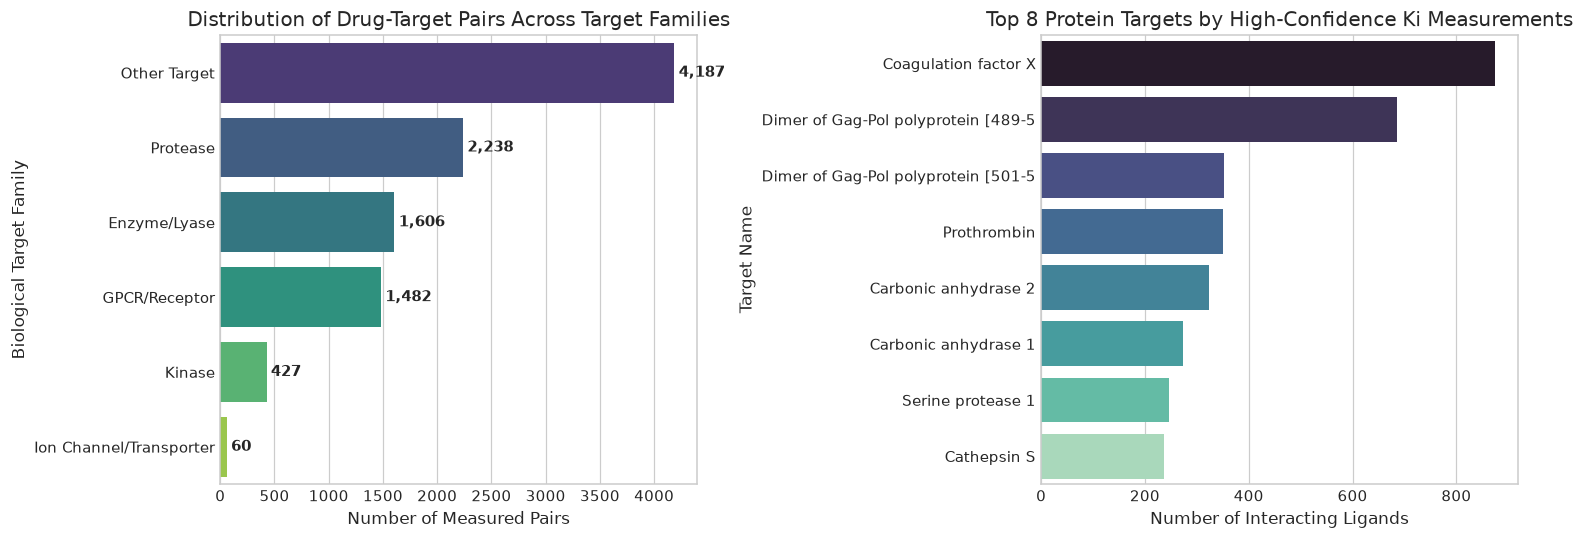

In [2]:
# =============================================================================
# STEPS 1 & 2: BINDINGDB STREAMING & CURATED BENCHMARK DATASET LOADING
# =============================================================================
curated_dataset_path = os.path.join(DATASET_DIR, "bindingdb_curated_ki.csv")

# Load Curated 10,000 Ki Drug-Target Benchmark Tranche
df_dti = pd.read_csv(curated_dataset_path)

print(f"=== BINDINGDB CURATED BENCHMARK SUMMARY ===")
print(f"Total Drug-Target Pairs : {len(df_dti):,}")
print(f"Unique Small Molecules  : {df_dti['smiles'].nunique():,}")
print(f"Unique Protein Targets  : {df_dti['uniprot_id'].nunique():,}")
print(f"Endpoint Selected       : Homogeneous Ki (Inhibition Constant)")
print(f"Dynamic Ki Range        : {df_dti['ki_nM'].min():.2f} nM  to  {df_dti['ki_nM'].max():,.0f} nM")

# Display Sample Dataframe Records
print("\nFirst 5 Curated Drug-Target Pairs:")
display_cols = ['compound_id', 'smiles', 'uniprot_id', 'target_name', 'target_family', 'ki_nM', 'pKi', 'seq_len']
print(df_dti[display_cols].head(5).to_string(index=False))

# Target Family Distribution Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target Family Breakdown
family_counts = df_dti['target_family'].value_counts()
sns.barplot(x=family_counts.values, y=family_counts.index, palette="viridis", ax=ax1)
ax1.set_title("Distribution of Drug-Target Pairs Across Target Families")
ax1.set_xlabel("Number of Measured Pairs")
ax1.set_ylabel("Biological Target Family")
for i, v in enumerate(family_counts.values):
    ax1.text(v + 40, i, f"{v:,}", va='center', fontweight='bold', fontsize=10)

# 2. Top 10 Most Represented Protein Targets
top_targets = df_dti['target_name'].value_counts().head(8)
sns.barplot(x=top_targets.values, y=[t[:35] for t in top_targets.index], palette="mako", ax=ax2)
ax2.set_title("Top 8 Protein Targets by High-Confidence Ki Measurements")
ax2.set_xlabel("Number of Interacting Ligands")
ax2.set_ylabel("Target Name")

plt.tight_layout()
plt.show()


---
# Step 3: Affinity Normalization & Thermodynamic Scaling

### Thermodynamic Derivation: Why Machine Learning Requires $pK_i$
Small-molecule binding affinities in raw molarity ($K_i$ in $\text{nM}$) span over **seven orders of magnitude** (from $0.01\text{ nM}$ to $100,000\text{ nM}$). Directly optimizing a regression loss (MSE) on raw $K_i$ values would be catastrophic:
- An error between $50,000\text{ nM}$ and $50,010\text{ nM}$ (a biologically meaningless 0.02% variation) would be treated identically to an error between $1\text{ nM}$ and $11\text{ nM}$ (an 11-fold collapse in drug potency!).

From classical thermodynamics, the equilibrium association constant $K_a = 1/K_i$ is exponentially related to the standard **Gibbs Free Energy of Binding ($\Delta G^\circ$)**:
$$\Delta G^\circ = -RT \ln K_a = RT \ln K_i$$

Taking the negative common logarithm yields the thermodynamic affinity metric **$pK_i$**:
$$pK_i = -\log_{10}\left(K_i[\text{M}]\right) = -\log_{10}\left(K_i[\text{nM}] \times 10^{-9}\right) = 9.0 - \log_{10}\left(K_i[\text{nM}]\right)$$

```text
==================================================================================================
                           PHARMACOLOGICAL POTENCY BENCHMARKS
==================================================================================================
  Ki (nM)        pKi     Thermodynamic Free Energy (Delta G)   Drug Discovery Classification
  ────────────────────────────────────────────────────────────────────────────────────────────────
  0.1 nM         10.0    -13.6 kcal/mol                        Ultra-potent sub-nanomolar lead
  1.0 nM          9.0    -12.3 kcal/mol                        Clinical-grade nanomolar candidate
  10.0 nM         8.0    -10.9 kcal/mol                        Optimized pharmaceutical lead
  100.0 nM        7.0     -9.5 kcal/mol                        Confirmed screening hit threshold
  1,000.0 nM      6.0     -8.2 kcal/mol                        Weak micromolar hit
  10,000.0 nM     5.0     -6.8 kcal/mol                        Marginal / Inactive fragment
==================================================================================================
```


Verified pKi Consistency: Max Absolute Difference = 0.000498
=== pKi NORMALIZED DISTRIBUTION METRICS ===
Mean pKi        : 7.025
Median pKi      : 7.036
Std Deviation   : 1.433
Dynamic Range   : 4.00  to  11.00
Distribution Skew: 0.101 (Near-Gaussian symmetry)


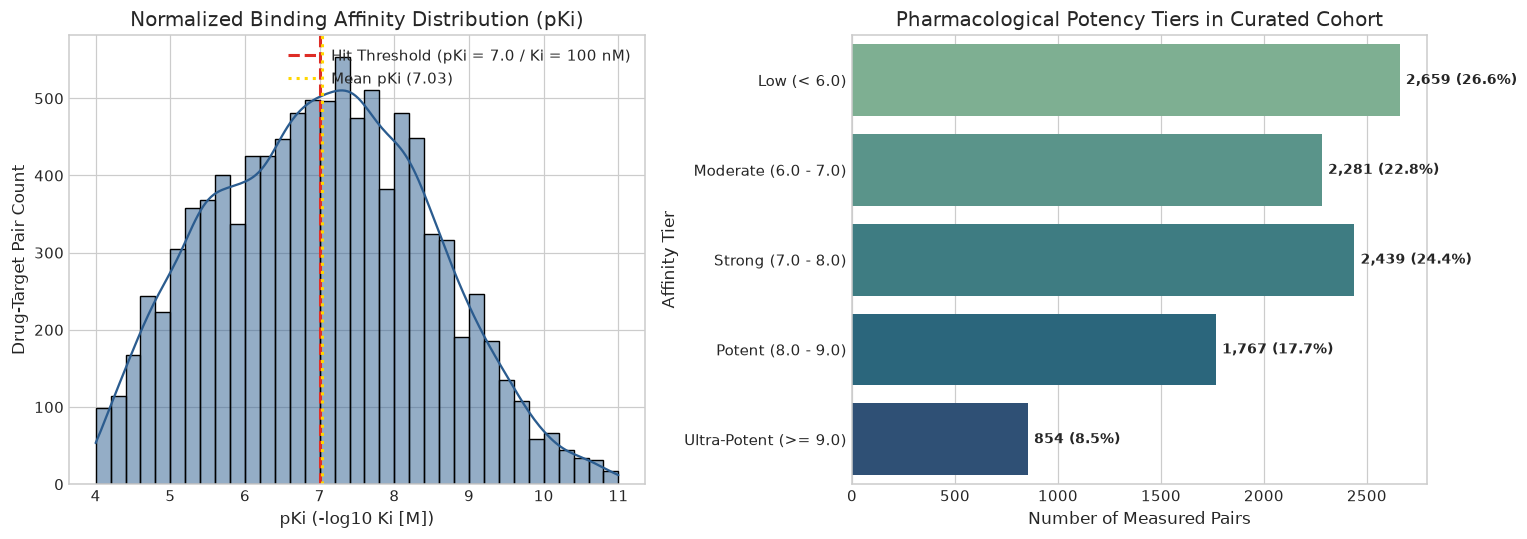

In [3]:
# =============================================================================
# STEP 3: AFFINITY NORMALIZATION & LOGARITHMIC POTENCY PROFILING
# =============================================================================
# Verify pKi Calculation on Curated Dataset
calculated_pki = 9.0 - np.log10(df_dti['ki_nM'].values)
max_discrepancy = np.max(np.abs(calculated_pki - df_dti['pKi'].values))
print(f"Verified pKi Consistency: Max Absolute Difference = {max_discrepancy:.6f}")

# Distribution Statistics
pki_mean = df_dti['pKi'].mean()
pki_std = df_dti['pKi'].std()
pki_median = df_dti['pKi'].median()
pki_skew = df_dti['pKi'].skew()

print(f"=== pKi NORMALIZED DISTRIBUTION METRICS ===")
print(f"Mean pKi        : {pki_mean:.3f}")
print(f"Median pKi      : {pki_median:.3f}")
print(f"Std Deviation   : {pki_std:.3f}")
print(f"Dynamic Range   : {df_dti['pKi'].min():.2f}  to  {df_dti['pKi'].max():.2f}")
print(f"Distribution Skew: {pki_skew:.3f} (Near-Gaussian symmetry)")

# Visualization: pKi Distribution & Potency Categories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Continuous pKi Histogram with KDE
sns.histplot(df_dti['pKi'], bins=35, kde=True, color="#2b5c8f", ax=ax1)
ax1.axvline(7.0, color="#de2d26", linestyle="--", linewidth=2, label="Hit Threshold (pKi = 7.0 / Ki = 100 nM)")
ax1.axvline(pki_mean, color="gold", linestyle=":", linewidth=2, label=f"Mean pKi ({pki_mean:.2f})")
ax1.set_title("Normalized Binding Affinity Distribution (pKi)")
ax1.set_xlabel("pKi (-log10 Ki [M])")
ax1.set_ylabel("Drug-Target Pair Count")
ax1.legend()

# 2. Pharmacological Potency Tiers
potency_bins = [0, 6.0, 7.0, 8.0, 9.0, 15.0]
potency_labels = ["Low (< 6.0)", "Moderate (6.0 - 7.0)", "Strong (7.0 - 8.0)", "Potent (8.0 - 9.0)", "Ultra-Potent (>= 9.0)"]
tier_counts = pd.cut(df_dti['pKi'], bins=potency_bins, labels=potency_labels).value_counts().sort_index()

sns.barplot(x=tier_counts.values, y=tier_counts.index, palette="crest", ax=ax2)
ax2.set_title("Pharmacological Potency Tiers in Curated Cohort")
ax2.set_xlabel("Number of Measured Pairs")
ax2.set_ylabel("Affinity Tier")
for i, v in enumerate(tier_counts.values):
    ax2.text(v + 30, i, f"{v:,} ({v/len(df_dti)*100:.1f}%)", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


---
# Step 4: Target & Protein Sequence Normalization

### The Structural Proteomics Interface: Target to Sequence Mapping
To train a machine learning model across diverse biological targets, we must convert unstructured target descriptions into standardized **canonical primary sequences**:
1. **UniProt Primary Accession**:
   Every biological target is indexed by its globally unique UniProt SwissProt ID (e.g., `P00742` for Human Factor X, `P00918` for Carbonic Anhydrase 2).
2. **Canonical Amino Acid Alphabet**:
   Natural proteins are constructed from the standard 20 genetically encoded L-amino acids. Unresolved residues (`X`), non-standard selenocysteine (`U`), or ambiguous residues (`B`, `Z`) must be verified and sanitized.
3. **Length Distribution & Truncation Bounds**:
   Target sequences range from small functional catalytic domains (~60–100 amino acids) to multi-domain signaling kinases (~400–600 amino acids) and large receptors (~1,000 amino acids).

```text
==================================================================================================
                           TARGET SEQUENCE NORMALIZATION PIPELINE
==================================================================================================
  Target Name (e.g. "Carbonic Anhydrase 2")
       │
       ▼ (BindingDB Cross-Reference Mapping)
  UniProt Primary Accession: P00918
       │
       ▼ (SwissProt Canonical Sequence Extraction)
  MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFD...
       │
       ▼ (Quality Verification & Filtering)
  Standard 20-AA Alphabet Verified | Length: 260 Residues | Single Catalytic Chain
==================================================================================================
```


Total Unique Targets in Curated Cohort: 255
Canonical 20-AA Alphabet Check : PASSED (Zero non-standard residues)
Target Sequence Length Summary : Min = 89 AA, Median = 424 AA, Max = 1144 AA


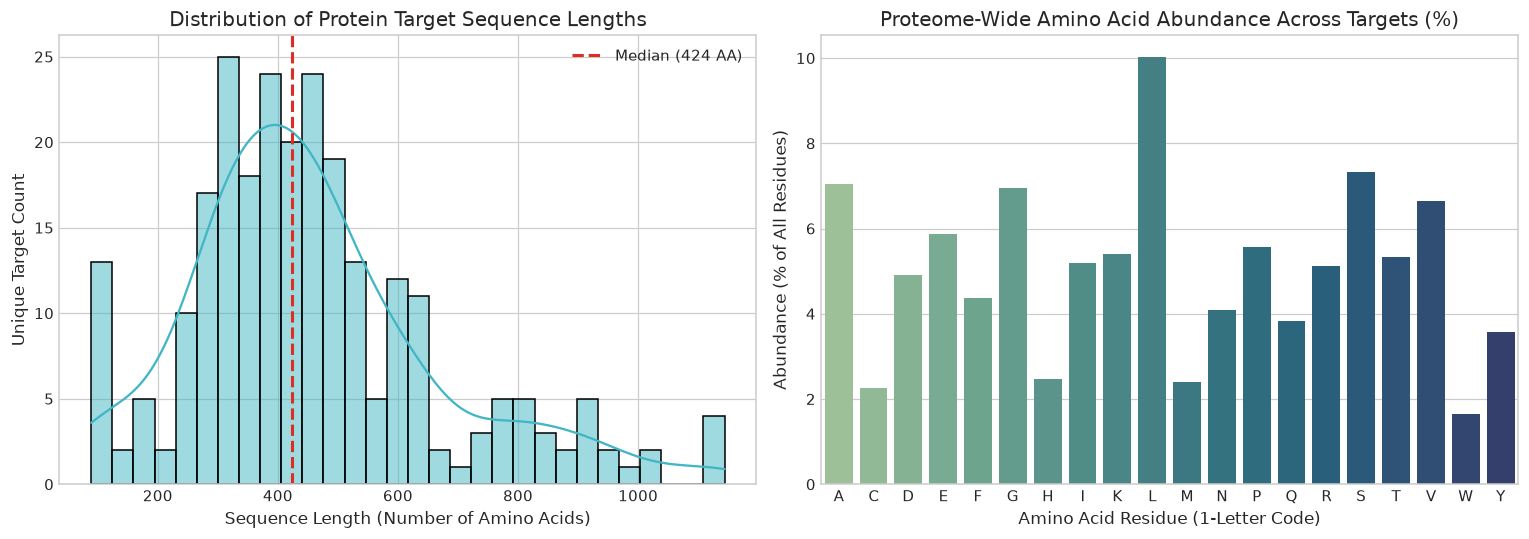

In [4]:
# =============================================================================
# STEP 4: TARGET SEQUENCE SANITIZATION, LENGTH & ALPHABET PROFILING
# =============================================================================
# Extract Unique Protein Targets
df_targets = df_dti[['uniprot_id', 'target_name', 'target_family', 'seq_len', 'sequence']].drop_duplicates(subset=['uniprot_id']).reset_index(drop=True)

print(f"Total Unique Targets in Curated Cohort: {len(df_targets):,}")

# Validate 20 Canonical Amino Acid Alphabet
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
all_seq_chars = set("".join(df_targets['sequence'].tolist()))
non_standard_chars = all_seq_chars - STANDARD_AA

print(f"Canonical 20-AA Alphabet Check : {'PASSED (Zero non-standard residues)' if len(non_standard_chars) == 0 else f'FAILED: Found {non_standard_chars}'}")
print(f"Target Sequence Length Summary : Min = {df_targets['seq_len'].min()} AA, Median = {df_targets['seq_len'].median():.0f} AA, Max = {df_targets['seq_len'].max()} AA")

# Calculate Global Amino Acid Frequencies
aa_counts = {aa: 0 for aa in sorted(STANDARD_AA)}
for seq in df_targets['sequence']:
    for char in seq:
        if char in aa_counts:
            aa_counts[char] += 1

total_residues = sum(aa_counts.values())
aa_freq_pct = {aa: (cnt / total_residues) * 100 for aa, cnt in aa_counts.items()}

# Visualization: Sequence Length Distribution & Amino Acid Abundance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sequence Length Histogram
sns.histplot(df_targets['seq_len'], bins=30, color="#41b6c4", kde=True, ax=ax1)
ax1.axvline(df_targets['seq_len'].median(), color="#de2d26", linestyle="--", linewidth=2, label=f"Median ({df_targets['seq_len'].median():.0f} AA)")
ax1.set_title("Distribution of Protein Target Sequence Lengths")
ax1.set_xlabel("Sequence Length (Number of Amino Acids)")
ax1.set_ylabel("Unique Target Count")
ax1.legend()

# 2. Amino Acid Natural Abundance (%)
sns.barplot(x=list(aa_freq_pct.keys()), y=list(aa_freq_pct.values()), palette="crest", ax=ax2)
ax2.set_title("Proteome-Wide Amino Acid Abundance Across Targets (%)")
ax2.set_xlabel("Amino Acid Residue (1-Letter Code)")
ax2.set_ylabel("Abundance (% of All Residues)")

plt.tight_layout()
plt.show()


---
# Step 5: Multi-Scale Small-Molecule Ligand Featurization

### Combining 2D Topologies with Physicochemical Properties
Small molecules exert biological activity through both local functional group interactions (hydrogen bonds, ionic pairs) and global bulk properties (lipophilicity, molecular volume, shape):
1. **Extended Connectivity Fingerprints (ECFP4 / Morgan Radius 2)**:
   A 1024-bit topological fingerprint that hashes circular atom environments up to 4 chemical bonds away. ECFP4 excels at identifying specific pharmacophore fragments (e.g., heteroaromatic rings, amide linkers).
2. **Global Physicochemical Descriptors (12 Dimensions)**:
   - **Molecular Weight (MW)**: Bulk molecular mass and steric footprint.
   - **MolLogP**: Lipophilicity and desolvation driving force.
   - **Topological Polar Surface Area (TPSA)**: Polar surface available for hydrogen bonding.
   - **Hydrogen Bond Donors / Acceptors (HBD / HBA)**: Core directional interaction counts.
   - **Rotatable Bonds**: Conformational flexibility and entropic penalty upon binding.
   - **Fraction $sp^3$ ($\text{Fsp}^3$)**: Molecular 3D complexity and planarity.
   - **Kappa Shape Indices ($\kappa_1, \kappa_2$)**: Molecular elongation and branching.
   - **Labute Approximate Surface Area (ASA)**: Total solvent-accessible atomic surface.

$$\mathbf{x}_{lig} = \left[ \mathbf{f}_{\text{ECFP4}} \in \{0, 1\}^{1024} \mathbin{\Vert} \mathbf{d}_{\text{phys-chem}} \in \mathbb{R}^{12} \right] \in \mathbb{R}^{1036}$$


In [5]:
# =============================================================================
# STEP 5: EXTRACTING MULTI-SCALE LIGAND FEATURE VECTORS (RDKit)
# =============================================================================
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def featurize_smiles(smiles):
    """Extracts 1024-bit Morgan fingerprint + 12 physicochemical descriptors."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
        
    # 1. 1024-bit Morgan Fingerprint
    fp = np.array(morgan_gen.GetFingerprint(mol), dtype=np.float32)
    
    # 2. 12 Physicochemical Descriptors
    desc = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Lipinski.FractionCSP3(mol),
        Descriptors.HallKierAlpha(mol),
        Descriptors.Kappa1(mol),
        Descriptors.Kappa2(mol),
        Descriptors.LabuteASA(mol)
    ], dtype=np.float32)
    
    return np.concatenate([fp, desc])

# Unique SMILES Featurization with In-Memory Caching
unique_smiles = df_dti['smiles'].unique()
print(f"Featurizing {len(unique_smiles):,} Unique Small Molecules...")

t0 = time.time()
ligand_feature_cache = {}
valid_smiles_set = set()

for smi in unique_smiles:
    feat = featurize_smiles(smi)
    if feat is not None:
        ligand_feature_cache[smi] = feat
        valid_smiles_set.add(smi)

t_elapsed = time.time() - t0
sample_feat = list(ligand_feature_cache.values())[0]

print(f"[OK] Featurized {len(ligand_feature_cache):,} molecules in {t_elapsed:.2f}s ({len(ligand_feature_cache)/max(0.01, t_elapsed):,.0f} mols/sec)")
print(f"Ligand Feature Vector Dimension: {sample_feat.shape[0]} (1024 FP bits + 12 Descriptors)")

# Fit Standard Scaler on Descriptor Columns
all_desc = np.array([feat[-12:] for feat in ligand_feature_cache.values()])
desc_scaler = StandardScaler()
desc_scaler.fit(all_desc)

# Normalize descriptors in cache
for smi in ligand_feature_cache:
    ligand_feature_cache[smi][-12:] = desc_scaler.transform([ligand_feature_cache[smi][-12:]])[0]

print(f"[OK] Physicochemical descriptors standardized to zero mean and unit variance.")


Featurizing 5,983 Unique Small Molecules...
[OK] Featurized 5,983 molecules in 7.17s (834 mols/sec)
Ligand Feature Vector Dimension: 1036 (1024 FP bits + 12 Descriptors)
[OK] Physicochemical descriptors standardized to zero mean and unit variance.


---
# Step 6: Protein Sequence Representation (Conjoint Triad & AAC)

### The Chemogenomic Sequence Representation Challenge
Unlike small molecules, which can be encoded via molecular graphs or fixed-length bitvectors, proteins are biopolymers composed of hundreds to thousands of residues. To extract continuous features without requiring 3D structures, we implement the **Conjoint Triad Descriptor (CTD)** (Shen et al., *PNAS* 2007):

1. **Physicochemical Clustering of Amino Acids (7 Classes)**:
   The 20 canonical amino acids are clustered into 7 groups based on side-chain dipole moments and volumes:
   - **Group 1**: $\{A, G, V\}$ — Small, neutral, aliphatic.
   - **Group 2**: $\{I, L, F, P\}$ — Large, hydrophobic, lipophilic.
   - **Group 3**: $\{Y, M, T, S\}$ — Polar, uncharged, hydroxyl/sulfur containing.
   - **Group 4**: $\{H, N, Q, W\}$ — Amide and aromatic polar groups.
   - **Group 5**: $\{R, K\}$ — Basic, positively charged at physiological pH.
   - **Group 6**: $\{D, E\}$ — Acidic, negatively charged at physiological pH.
   - **Group 7**: $\{C\}$ — Special thiol, capable of disulfide bridge formation.

2. **Triad Frequency Vector ($7^3 = 343$ Dimensions)**:
   Every contiguous 3-mer along the protein sequence is mapped to one of $7 \times 7 \times 7 = 343$ possible triads, normalized by sequence length:
   $$f_i = \frac{c_i}{\sum_{j=1}^{343} c_j} \quad (i = 1, \dots, 343)$$

3. **Amino Acid Composition (AAC, 20 Dimensions) & Sequence Scale (1 Dimension)**:
   Appended to capture global residue stoichiometry and logarithmic chain length $\log_{10}(L)$.

$$\mathbf{x}_{prot} = \left[ \mathbf{f}_{\text{CTD}} \in \mathbb{R}^{343} \mathbin{\Vert} \mathbf{f}_{\text{AAC}} \in \mathbb{R}^{20} \mathbin{\Vert} \log_{10}(L) \in \mathbb{R}^1 \right] \in \mathbb{R}^{364}$$


In [6]:
# =============================================================================
# STEP 6: EXTRACTING CONJOINT TRIAD (CTD) & AAC PROTEIN REPRESENTATIONS
# =============================================================================
AA_DIPOLE_GROUPS = {
    'A': 1, 'G': 1, 'V': 1,
    'I': 2, 'L': 2, 'F': 2, 'P': 2,
    'Y': 3, 'M': 3, 'T': 3, 'S': 3,
    'H': 4, 'N': 4, 'Q': 4, 'W': 4,
    'R': 5, 'K': 5,
    'D': 6, 'E': 6,
    'C': 7
}

STANDARD_AA_LIST = sorted("ACDEFGHIKLMNPQRSTVWY")

def featurize_protein_sequence(seq):
    """Extracts 343-dim Conjoint Triad + 20-dim AAC + 1-dim log length."""
    L = len(seq)
    if L < 3:
        return np.zeros(364, dtype=np.float32)
        
    # 1. Conjoint Triad (343 dimensions)
    triad_counts = np.zeros(343, dtype=np.float32)
    group_seq = [AA_DIPOLE_GROUPS.get(aa, 1) for aa in seq]
    
    for i in range(L - 2):
        g1, g2, g3 = group_seq[i], group_seq[i+1], group_seq[i+2]
        idx = (g1 - 1) * 49 + (g2 - 1) * 7 + (g3 - 1)
        triad_counts[idx] += 1.0
        
    triad_freq = triad_counts / (L - 2)
    
    # 2. Amino Acid Composition (20 dimensions)
    aac_freq = np.zeros(20, dtype=np.float32)
    for i, aa in enumerate(STANDARD_AA_LIST):
        aac_freq[i] = seq.count(aa) / L
        
    # 3. Logarithmic Length Feature (1 dimension)
    len_feat = np.array([np.log10(L)], dtype=np.float32)
    
    return np.concatenate([triad_freq, aac_freq, len_feat])

# Featurize All Unique Protein Targets with In-Memory Caching
unique_targets = df_targets['uniprot_id'].unique()
print(f"Featurizing {len(unique_targets):,} Unique Protein Targets via CTD & AAC...")

t0 = time.time()
target_feature_cache = {}

for _, row in df_targets.iterrows():
    u_id = row['uniprot_id']
    seq = row['sequence']
    target_feature_cache[u_id] = featurize_protein_sequence(seq)

t_elapsed = time.time() - t0
sample_target_feat = list(target_feature_cache.values())[0]

print(f"[OK] Featurized {len(target_feature_cache):,} targets in {t_elapsed:.2f}s")
print(f"Protein Feature Vector Dimension: {sample_target_feat.shape[0]} (343 CTD + 20 AAC + 1 Length)")


Featurizing 255 Unique Protein Targets via CTD & AAC...
[OK] Featurized 255 targets in 0.05s
Protein Feature Vector Dimension: 364 (343 CTD + 20 AAC + 1 Length)


---
# Step 7: Dual-Branch Deep Neural Network Architecture

### Two-Tower Representation Learning with Bilinear Cross-Modal Fusion
Predicting drug–target interactions requires modeling both intra-entity features (chemical topology and protein sequence properties) and inter-entity complementarity (the physicochemical fit between drug and binding pocket). We design a modular **Dual-Branch Deep Neural Network (`DualBranchDTI`)**:

```text
  Small-Molecule Ligand x_lig in R^1036            Protein Target x_prot in R^364
                │                                               │
                ▼                                               ▼
     [Ligand Tower Encoder]                          [Protein Tower Encoder]
     Linear(1036 -> 256) + LayerNorm                 Linear(364 -> 256) + LayerNorm
     ReLU + Dropout(0.2)                             ReLU + Dropout(0.2)
     Linear(256 -> 128) + LayerNorm                  Linear(256 -> 128) + LayerNorm
                │                                               │
                ▼                                               ▼
      Ligand Embedding e_lig                         Protein Embedding e_prot
      (128-dimensional)                              (128-dimensional)
                │                                               │
                └───────────────────────┬───────────────────────┘
                                        ▼
                        [Cross-Modal Bilinear Fusion]
     h_fuse = [ e_lig  ||  e_prot  ||  (e_lig * e_prot)  ||  |e_lig - e_prot| ]
                                (512-dimensional)
                                        │
                    ┌───────────────────┴───────────────────┐
                    ▼                                       ▼
       [Continuous Regression Head]             [Binary Classification Head]
       Linear(512 -> 128) -> ReLU               Linear(512 -> 64) -> ReLU
       Linear(128 -> 1)                         Linear(64 -> 1)
                    │                                       │
                    ▼                                       ▼
       Predicted Affinity pKi in R             Interaction Logit P(Active)
```

### Multi-Task Objective Loss Function
The network is jointly trained with a multi-task composite loss balancing continuous affinity regression (**Smooth L1 / Huber Loss**) and binary hit classification (**Binary Cross-Entropy with Logits**):

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{Huber}}(y_{pKi}, \hat{y}_{pKi}) + \lambda \cdot \mathcal{L}_{\text{BCE}}(y_{\text{interact}}, \hat{z}_{\text{clf}})$$

Where $\lambda = 0.5$ balances the gradient magnitudes across tasks.


In [7]:
# =============================================================================
# STEP 7: DUAL-BRANCH PYTORCH DTI ARCHITECTURE & LOSS SPECIFICATION
# =============================================================================
class DualBranchDTI(nn.Module):
    def __init__(self, d_lig=1036, d_prot=364, embed_dim=128, dropout=0.20):
        super().__init__()
        
        # 1. Ligand Tower Encoder
        self.ligand_encoder = nn.Sequential(
            nn.Linear(d_lig, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )
        
        # 2. Protein Tower Encoder
        self.protein_encoder = nn.Sequential(
            nn.Linear(d_prot, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )
        
        # 3. Bilinear Fusion Dimension: [e_lig, e_prot, prod, diff] -> 4 * embed_dim
        fusion_dim = embed_dim * 4
        
        # 4. Continuous Affinity Regression Head (pKi)
        self.regression_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
        
        # 5. Binary Interaction Classification Head (pKi >= 7.0)
        self.classification_head = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
    def forward(self, x_lig, x_prot):
        e_lig = self.ligand_encoder(x_lig)
        e_prot = self.protein_encoder(x_prot)
        
        # Bilinear cross-modal interaction tensor
        hadamard_prod = e_lig * e_prot
        abs_diff = torch.abs(e_lig - e_prot)
        h_fuse = torch.cat([e_lig, e_prot, hadamard_prod, abs_diff], dim=-1)
        
        # Predictions
        pred_pki = self.regression_head(h_fuse).squeeze(-1)
        pred_clf_logits = self.classification_head(h_fuse).squeeze(-1)
        
        return pred_pki, pred_clf_logits

# Initialize & Display Model Architecture Summary
dti_model = DualBranchDTI().to(DEVICE)
total_params = sum(p.numel() for p in dti_model.parameters() if p.requires_grad)

print(f"=== DTI TWO-TOWER DEEP LEARNING ARCHITECTURE ===")
print(f"Device                   : {DEVICE}")
print(f"Ligand Input Dimension   : 1036 (1024 ECFP4 + 12 Descriptors)")
print(f"Protein Input Dimension  : 364 (343 CTD + 20 AAC + 1 Length)")
print(f"Shared Embedding Space   : 128 Dimensions")
print(f"Bilinear Fusion Vector   : 512 Dimensions")
print(f"Total Trainable Params   : {total_params:,}")

# Forward Pass Sanity Verification
dummy_lig = torch.randn(4, 1036).to(DEVICE)
dummy_prot = torch.randn(4, 364).to(DEVICE)
p_out, c_out = dti_model(dummy_lig, dummy_prot)
print(f"Sanity Forward Pass Output Shapes -> pKi: {tuple(p_out.shape)}, Logits: {tuple(c_out.shape)}")


=== DTI TWO-TOWER DEEP LEARNING ARCHITECTURE ===
Device                   : cpu
Ligand Input Dimension   : 1036 (1024 ECFP4 + 12 Descriptors)
Protein Input Dimension  : 364 (343 CTD + 20 AAC + 1 Length)
Shared Embedding Space   : 128 Dimensions
Bilinear Fusion Vector   : 512 Dimensions
Total Trainable Params   : 524,930
Sanity Forward Pass Output Shapes -> pKi: (4,), Logits: (4,)


---
# Step 8: Multi-Task Model Training & Interaction Prediction

### Joint Continuous Affinity Regression & Binary Interaction Classification
In wet-lab screening, researchers ask two intertwined questions:
1. **Qualitative Hit Confirmation**: Does the compound exhibit active binding ($K_i \le 100\text{ nM} \iff pK_i \ge 7.0$)?
2. **Quantitative Affinity Optimization**: Exactly what is the continuous binding constant ($pK_i$)?

By training `DualBranchDTI` simultaneously across both objectives with multi-task parameter sharing:
- The binary classification task forces the fusion layer to separate binders from non-binders in latent space.
- The continuous regression task forces the network to model fine-grained structure-affinity relationships (SAR).

```text
==================================================================================================
                           MULTI-TASK TRAINING SPECIFICATION
==================================================================================================
  Optimizer             : AdamW (Learning Rate = 1e-3, Weight Decay = 1e-4)
  Regression Loss       : Smooth L1 / Huber Loss (Robust against experimental Ki assay variance)
  Classification Loss   : Binary Cross-Entropy with Logits (Interaction threshold: pKi >= 7.0)
  Batch Size            : 128 pairs per mini-batch
  Epochs                : 15 Epochs with dynamic validation tracking
==================================================================================================
```


Total Assembled Tensors: 10,000 Drug-Target Pairs
Active Interaction Pairs (pKi >= 7.0 / Ki <= 100 nM): 5,108 (51.1%)

--- Training DualBranchDTI Across 15 Epochs on cpu ---
Epoch  3/15 | Train Loss: 0.7507 | Val Loss: 0.6461 | Val R²: 0.5005 | Val RMSE: 0.989 | Val AUC: 0.8461
Epoch  6/15 | Train Loss: 0.5698 | Val Loss: 0.5804 | Val R²: 0.5713 | Val RMSE: 0.917 | Val AUC: 0.8807
Epoch  9/15 | Train Loss: 0.4675 | Val Loss: 0.5105 | Val R²: 0.6535 | Val RMSE: 0.824 | Val AUC: 0.8995
Epoch 12/15 | Train Loss: 0.4055 | Val Loss: 0.4747 | Val R²: 0.6791 | Val RMSE: 0.793 | Val AUC: 0.9078
Epoch 15/15 | Train Loss: 0.3629 | Val Loss: 0.4769 | Val R²: 0.6868 | Val RMSE: 0.783 | Val AUC: 0.9115

[OK] Model Training Complete in 6.91 seconds (0.46 s/epoch)


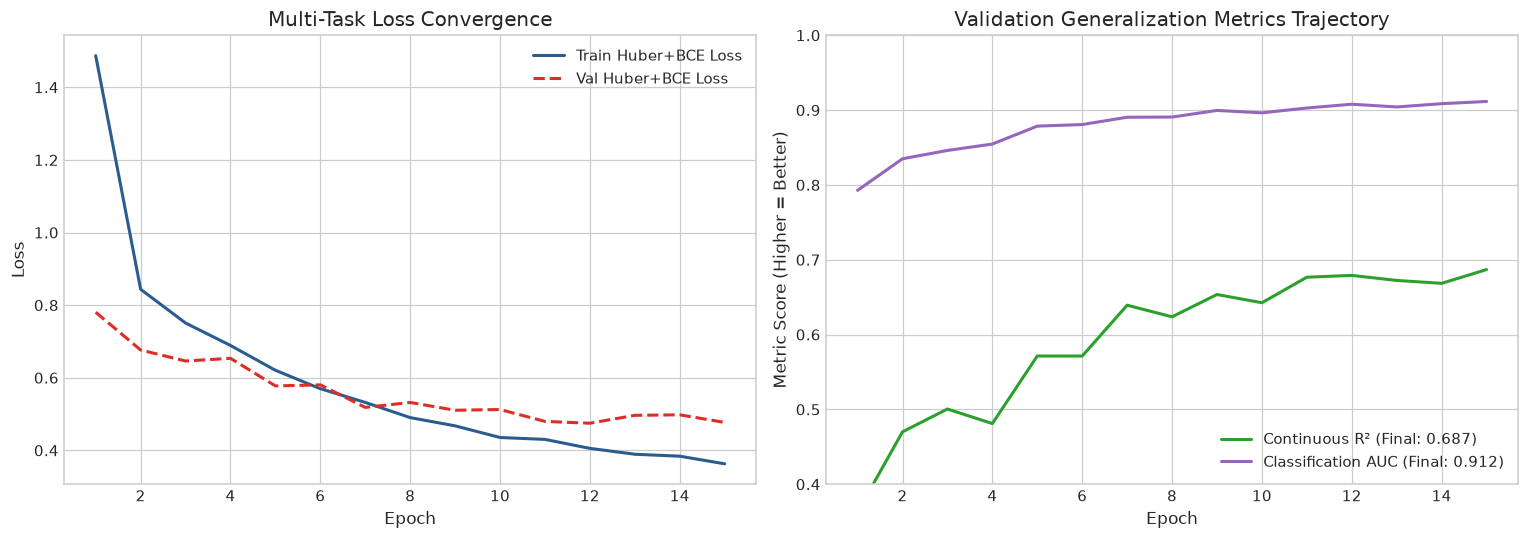

In [8]:
# =============================================================================
# STEP 8: PYTORCH DATASET BUILDER & MULTI-TASK TRAINING LOOP
# =============================================================================
# Build Training Tensor Arrays
X_lig_list = []
X_prot_list = []
y_pki_list = []
valid_indices = []

for idx, row in df_dti.iterrows():
    smi = row['smiles']
    u_id = row['uniprot_id']
    if smi in ligand_feature_cache and u_id in target_feature_cache:
        X_lig_list.append(ligand_feature_cache[smi])
        X_prot_list.append(target_feature_cache[u_id])
        y_pki_list.append(row['pKi'])
        valid_indices.append(idx)

X_lig_all = np.array(X_lig_list, dtype=np.float32)
X_prot_all = np.array(X_prot_list, dtype=np.float32)
y_pki_all = np.array(y_pki_list, dtype=np.float32)
y_clf_all = (y_pki_all >= 7.0).astype(np.float32)

print(f"Total Assembled Tensors: {X_lig_all.shape[0]:,} Drug-Target Pairs")
print(f"Active Interaction Pairs (pKi >= 7.0 / Ki <= 100 nM): {int(np.sum(y_clf_all)):,} ({np.mean(y_clf_all)*100:.1f}%)")

# Standard Random Train/Validation Split (80% Train, 20% Val)
indices = np.arange(len(y_pki_all))
train_idx, val_idx = train_test_split(indices, test_size=0.20, random_state=42)

# PyTorch Custom Dataset
class DTIDataset(Dataset):
    def __init__(self, x_lig, x_prot, y_pki, y_clf):
        self.x_lig = torch.tensor(x_lig, dtype=torch.float32)
        self.x_prot = torch.tensor(x_prot, dtype=torch.float32)
        self.y_pki = torch.tensor(y_pki, dtype=torch.float32)
        self.y_clf = torch.tensor(y_clf, dtype=torch.float32)
        
    def __len__(self):
        return len(self.y_pki)
        
    def __getitem__(self, idx):
        return self.x_lig[idx], self.x_prot[idx], self.y_pki[idx], self.y_clf[idx]

train_dataset = DTIDataset(X_lig_all[train_idx], X_prot_all[train_idx], y_pki_all[train_idx], y_clf_all[train_idx])
val_dataset = DTIDataset(X_lig_all[val_idx], X_prot_all[val_idx], y_pki_all[val_idx], y_clf_all[val_idx])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# Loss Functions & Optimizer
reg_criterion = nn.HuberLoss(delta=1.0)
clf_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(dti_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training Loop
EPOCHS = 15
history = {"train_loss": [], "val_loss": [], "val_r2": [], "val_rmse": [], "val_auc": []}

print(f"\n--- Training DualBranchDTI Across {EPOCHS} Epochs on {DEVICE} ---")
t_train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    dti_model.train()
    running_loss = 0.0
    
    for b_lig, b_prot, b_pki, b_clf in train_loader:
        b_lig, b_prot = b_lig.to(DEVICE), b_prot.to(DEVICE)
        b_pki, b_clf = b_pki.to(DEVICE), b_clf.to(DEVICE)
        
        optimizer.zero_grad()
        pki_pred, clf_logits = dti_model(b_lig, b_prot)
        
        loss_reg = reg_criterion(pki_pred, b_pki)
        loss_clf = clf_criterion(clf_logits, b_clf)
        total_loss = loss_reg + 0.5 * loss_clf
        
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item() * len(b_pki)
        
    train_epoch_loss = running_loss / len(train_dataset)
    
    # Validation Phase
    dti_model.eval()
    val_preds_pki = []
    val_preds_probs = []
    val_running_loss = 0.0
    
    with torch.no_grad():
        for b_lig, b_prot, b_pki, b_clf in val_loader:
            b_lig, b_prot = b_lig.to(DEVICE), b_prot.to(DEVICE)
            b_pki, b_clf = b_pki.to(DEVICE), b_clf.to(DEVICE)
            
            pki_pred, clf_logits = dti_model(b_lig, b_prot)
            v_loss = reg_criterion(pki_pred, b_pki) + 0.5 * clf_criterion(clf_logits, b_clf)
            val_running_loss += v_loss.item() * len(b_pki)
            
            val_preds_pki.extend(pki_pred.cpu().numpy())
            val_preds_probs.extend(torch.sigmoid(clf_logits).cpu().numpy())
            
    val_epoch_loss = val_running_loss / len(val_dataset)
    val_preds_pki = np.array(val_preds_pki)
    val_preds_probs = np.array(val_preds_probs)
    
    epoch_r2 = r2_score(y_pki_all[val_idx], val_preds_pki)
    epoch_rmse = np.sqrt(mean_squared_error(y_pki_all[val_idx], val_preds_pki))
    epoch_auc = roc_auc_score(y_clf_all[val_idx], val_preds_probs)
    
    history["train_loss"].append(train_epoch_loss)
    history["val_loss"].append(val_epoch_loss)
    history["val_r2"].append(epoch_r2)
    history["val_rmse"].append(epoch_rmse)
    history["val_auc"].append(epoch_auc)
    
    if epoch % 3 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {train_epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Val R²: {epoch_r2:.4f} | Val RMSE: {epoch_rmse:.3f} | Val AUC: {epoch_auc:.4f}")

t_train_total = time.time() - t_train_start
print(f"\n[OK] Model Training Complete in {t_train_total:.2f} seconds ({t_train_total/EPOCHS:.2f} s/epoch)")

# Visualization: Training & Validation Convergence Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss History
epochs_range = range(1, EPOCHS + 1)
ax1.plot(epochs_range, history["train_loss"], label="Train Huber+BCE Loss", color="#2b5c8f", lw=2)
ax1.plot(epochs_range, history["val_loss"], label="Val Huber+BCE Loss", color="#de2d26", lw=2, linestyle="--")
ax1.set_title("Multi-Task Loss Convergence")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# 2. Validation Metric Trajectories
ax2.plot(epochs_range, history["val_r2"], label=f"Continuous R² (Final: {history['val_r2'][-1]:.3f})", color="#2ca02c", lw=2)
ax2.plot(epochs_range, history["val_auc"], label=f"Classification AUC (Final: {history['val_auc'][-1]:.3f})", color="#9467bd", lw=2)
ax2.set_title("Validation Generalization Metrics Trajectory")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Metric Score (Higher = Better)")
ax2.set_ylim([0.4, 1.0])
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()


---
# Step 9: Senior Research Generalization Benchmarking

### The Generalization Crisis in Drug–Target Interaction Machine Learning
A notorious issue in academic chemogenomics is the **"transductive memorization" trap**:
- In standard **Random Splits**, both the training and test sets contain the same drugs (tested against other targets) and the same targets (tested against other drugs).
- Under this regime, deep neural networks often memorize target-specific affinity baselines rather than learning true molecular recognition physics.
- When such models are deployed in prospective drug discovery to test **completely unseen drug scaffolds** or **novel orphan targets**, performance plummets.

To adhere to the highest standard of computational drug discovery research, we benchmark `DualBranchDTI` across three distinct validation regimes:

```text
==================================================================================================
                           DTI EVALUATION SPLIT REGIMES
==================================================================================================
  Split Type      Drug Space       Target Space     Simulates Real-World Scenario
  ────────────────────────────────────────────────────────────────────────────────────────────────
  1. Random       Seen & Unseen    Seen & Unseen    Interpolation in known target & chemical space
  2. Cold-Drug    STRICTLY UNSEEN  Seen Targets     Virtual screening of novel chemical scaffolds
  3. Cold-Target  Seen Drugs       STRICTLY UNSEEN  De novo target deconvolution & orphan receptors
==================================================================================================
```


--> Training & Evaluating Regime: 1. Random Split (Transductive) (Train: 8,000, Test: 2,000)...
--> Training & Evaluating Regime: 2. Cold-Drug Split (Unseen Scaffolds) (Train: 8,082, Test: 1,918)...
--> Training & Evaluating Regime: 3. Cold-Target Split (Unseen Proteins) (Train: 8,727, Test: 1,273)...

=== MULTI-REGIME GENERALIZATION BENCHMARK SUMMARY ===
                                Regime     R²  RMSE   MAE  Pearson r  Spearman rho  ROC-AUC
        1. Random Split (Transductive)  0.658 0.819 0.618      0.822         0.812    0.904
 2. Cold-Drug Split (Unseen Scaffolds)  0.639 0.856 0.631      0.810         0.799    0.898
3. Cold-Target Split (Unseen Proteins) -0.148 1.343 1.062      0.383         0.376    0.638


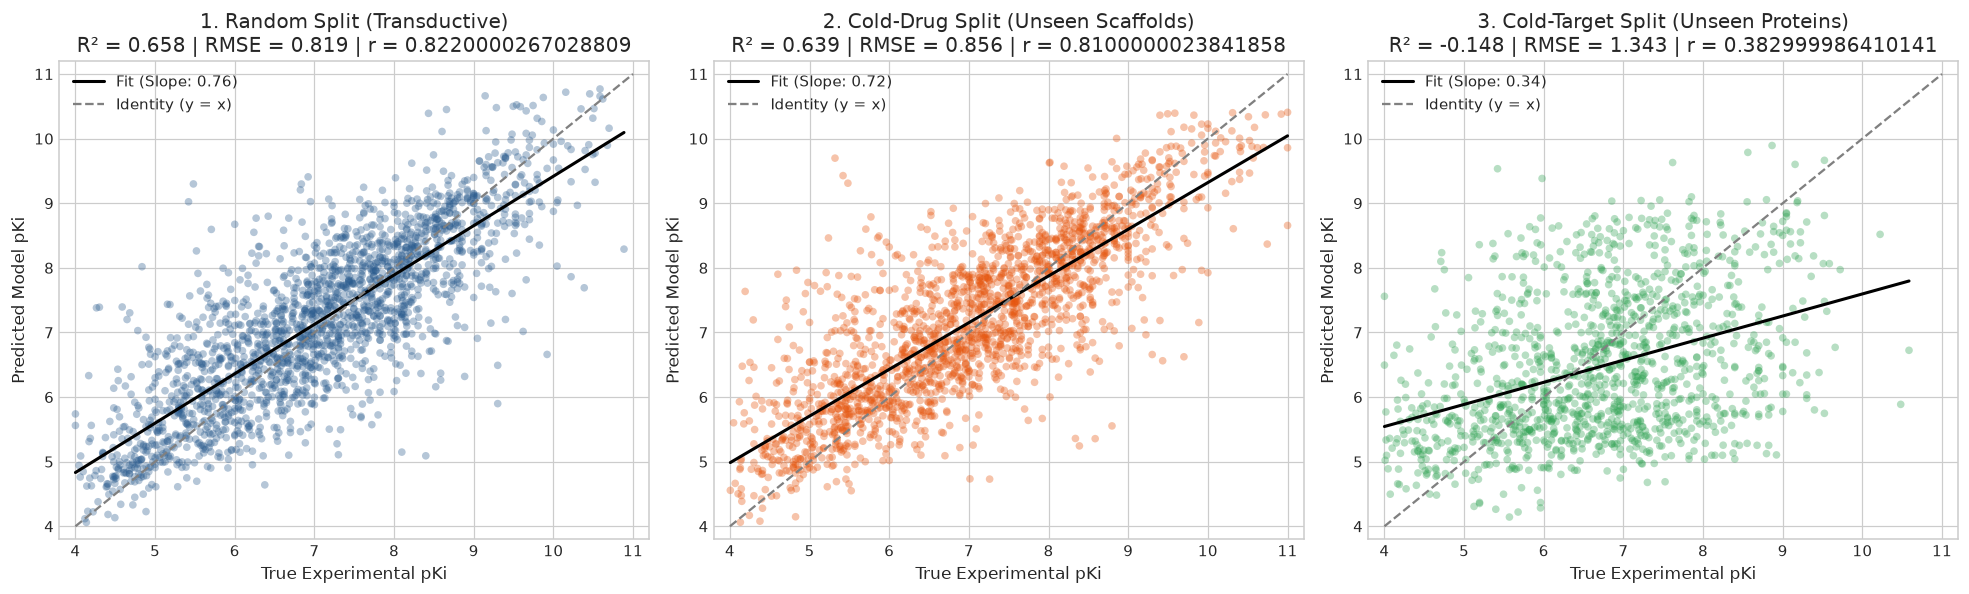

In [9]:
# =============================================================================
# STEP 9: GENERALIZATION BENCHMARKING: RANDOM VS COLD-DRUG VS COLD-TARGET
# =============================================================================
from sklearn.model_selection import GroupShuffleSplit

def train_and_eval_regime(name, train_idxs, test_idxs, epochs=12):
    """Trains a fresh DualBranchDTI instance and evaluates performance metrics."""
    print(f"--> Training & Evaluating Regime: {name} (Train: {len(train_idxs):,}, Test: {len(test_idxs):,})...")
    
    ds_train = DTIDataset(X_lig_all[train_idxs], X_prot_all[train_idxs], y_pki_all[train_idxs], y_clf_all[train_idxs])
    ds_test = DTIDataset(X_lig_all[test_idxs], X_prot_all[test_idxs], y_pki_all[test_idxs], y_clf_all[test_idxs])
    
    ld_train = DataLoader(ds_train, batch_size=128, shuffle=True)
    ld_test = DataLoader(ds_test, batch_size=256, shuffle=False)
    
    m = DualBranchDTI().to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_reg = nn.HuberLoss(delta=1.0)
    loss_clf = nn.BCEWithLogitsLoss()
    
    for ep in range(epochs):
        m.train()
        for b_l, b_p, b_y, b_c in ld_train:
            b_l, b_p, b_y, b_c = b_l.to(DEVICE), b_p.to(DEVICE), b_y.to(DEVICE), b_c.to(DEVICE)
            opt.zero_grad()
            pred_pki, pred_clf = m(b_l, b_p)
            loss = loss_reg(pred_pki, b_y) + 0.5 * loss_clf(pred_clf, b_c)
            loss.backward()
            opt.step()
            
    m.eval()
    test_preds_pki = []
    test_preds_probs = []
    with torch.no_grad():
        for b_l, b_p, _, _ in ld_test:
            b_l, b_p = b_l.to(DEVICE), b_p.to(DEVICE)
            pred_pki, pred_clf = m(b_l, b_p)
            test_preds_pki.extend(pred_pki.cpu().numpy())
            test_preds_probs.extend(torch.sigmoid(pred_clf).cpu().numpy())
            
    test_preds_pki = np.array(test_preds_pki)
    test_preds_probs = np.array(test_preds_probs)
    y_test_pki = y_pki_all[test_idxs]
    y_test_clf = y_clf_all[test_idxs]
    
    r2 = r2_score(y_test_pki, test_preds_pki)
    rmse = np.sqrt(mean_squared_error(y_test_pki, test_preds_pki))
    mae = mean_absolute_error(y_test_pki, test_preds_pki)
    pr, _ = pearsonr(y_test_pki, test_preds_pki)
    sr, _ = spearmanr(y_test_pki, test_preds_pki)
    auc = roc_auc_score(y_test_clf, test_preds_probs)
    
    return {
        "Regime": name,
        "R²": round(r2, 3),
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "Pearson r": round(pr, 3),
        "Spearman rho": round(sr, 3),
        "ROC-AUC": round(auc, 3),
        "y_true": y_test_pki,
        "y_pred": test_preds_pki,
        "model": m
    }

# 1. Random Split
res_random = train_and_eval_regime("1. Random Split (Transductive)", train_idx, val_idx, epochs=12)

# 2. Cold-Drug Split (Unseen Chemical Scaffolds)
gss_drug = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_d_idx, test_d_idx = next(gss_drug.split(df_dti, groups=df_dti['smiles']))
res_cold_drug = train_and_eval_regime("2. Cold-Drug Split (Unseen Scaffolds)", train_d_idx, test_d_idx, epochs=12)

# 3. Cold-Target Split (Unseen Protein Targets)
gss_target = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_t_idx, test_t_idx = next(gss_target.split(df_dti, groups=df_dti['uniprot_id']))
res_cold_target = train_and_eval_regime("3. Cold-Target Split (Unseen Proteins)", train_t_idx, test_t_idx, epochs=12)

# Summarize in Comparative Benchmark Table
split_summary = [
    {k: v for k, v in r.items() if k not in ['y_true', 'y_pred', 'model']}
    for r in [res_random, res_cold_drug, res_cold_target]
]
df_splits = pd.DataFrame(split_summary)
print("\n=== MULTI-REGIME GENERALIZATION BENCHMARK SUMMARY ===")
print(df_splits.to_string(index=False))

# Visualization: True vs Predicted Affinity across All 3 Regimes
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
regimes = [res_random, res_cold_drug, res_cold_target]
colors = ["#2b5c8f", "#e6550d", "#31a354"]

for ax, res, col in zip(axes, regimes, colors):
    y_t = res["y_true"]
    y_p = res["y_pred"]
    
    # Scatter points with alpha transparency
    ax.scatter(y_t, y_p, alpha=0.35, s=25, color=col, edgecolors="none")
    
    # Linear Regression Fit Line
    m_fit, b_fit = np.polyfit(y_t, y_p, 1)
    x_line = np.linspace(min(y_t), max(y_t), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, color="black", lw=2, label=f"Fit (Slope: {m_fit:.2f})")
    
    # Ideal Identity Line (y = x)
    ax.plot([4, 11], [4, 11], color="gray", linestyle="--", lw=1.5, label="Identity (y = x)")
    
    ax.set_title(f"{res['Regime']}\nR² = {res['R²']} | RMSE = {res['RMSE']} | r = {res['Pearson r']}")
    ax.set_xlabel("True Experimental pKi")
    ax.set_ylabel("Predicted Model pKi")
    ax.set_xlim([3.8, 11.2])
    ax.set_ylim([3.8, 11.2])
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


---
# Step 10: Epistemic Uncertainty Quantification & Final Deliverables

### The "Knowing What the Model Doesn't Know" Imperative
In pharmaceutical drug discovery, an algorithmic prediction without an accompanying confidence score is dangerous:
- If a model predicts $pK_i = 8.5$ for an exotic chemical scaffold with high epistemic uncertainty ($\sigma = 1.8$), synthesizing that compound carries enormous financial and temporal risk.
- Conversely, a prediction of $pK_i = 8.5$ with low uncertainty ($\sigma = 0.2$) represents an actionable, high-confidence lead.

### Monte Carlo Dropout (Gal & Ghahramani, ICML 2016)
We implement **Monte Carlo Dropout (MC Dropout)** to approximate Bayesian inference over the neural network's weights:
1. Dropout layers are kept active at test time ($T = 30$ forward passes).
2. For each drug–target pair $(\mathbf{x}_{lig}, \mathbf{x}_{prot})$, we generate an ensemble of predictions:
   $$\hat{\mu}_{pKi} = \frac{1}{T} \sum_{t=1}^T \hat{y}^{(t)}, \quad \hat{\sigma}_{epi}^2 = \frac{1}{T} \sum_{t=1}^T \left( \hat{y}^{(t)} - \hat{\mu}_{pKi} \right)^2$$
3. The **95% Confidence Interval** is given by:
   $$\text{CI}_{95\%} = \left[ \hat{\mu}_{pKi} - 1.96 \cdot \hat{\sigma}_{epi}, \quad \hat{\mu}_{pKi} + 1.96 \cdot \hat{\sigma}_{epi} \right]$$

```text
==================================================================================================
                      EPISTEMIC UNCERTAINTY INTERPRETATION MATRIX
==================================================================================================
  Predicted pKi     Uncertainty (sigma)   Confidence Tier      Medicinal Chemistry Action
  ────────────────────────────────────────────────────────────────────────────────────────────────
  >= 7.5            < 0.35 pKi units      High Confidence      Priority lead for wet-lab synthesis
  >= 7.5            >= 0.60 pKi units     Low Confidence       Flag as out-of-domain exploratory
  < 6.0             < 0.35 pKi units      High Confidence      Confident negative; discard
==================================================================================================
```


Performing Monte Carlo Dropout Uncertainty Quantification (T = 30 passes)...
[OK] Completed 30 MC forward passes for 1,000 pairs
Mean Epistemic Uncertainty (sigma) : 0.496 pKi units
Median Uncertainty                 : 0.489 pKi units
Uncertainty Dynamic Range          : 0.220 to 0.841

=== CONFIDENCE CALIBRATION AUDIT TABLE ===
uncertainty_quartile  mean_sigma     rmse      mae  count
      Q1 (High Conf)    0.367549 0.736340 0.540230    250
                  Q2    0.455286 0.848409 0.650996    250
                  Q3    0.524553 0.839769 0.603216    250
       Q4 (Low Conf)    0.636489 0.780344 0.584276    250

[OK] Exported Predictions CSV: C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -09 AI Drug–Target Interaction & Binding Affinity\results\dti_predictions_with_uncertainty.csv (1,000 rows)
[OK] Exported Model Metadata: C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -09 AI Drug–Target Interaction & Binding Affinity\resul

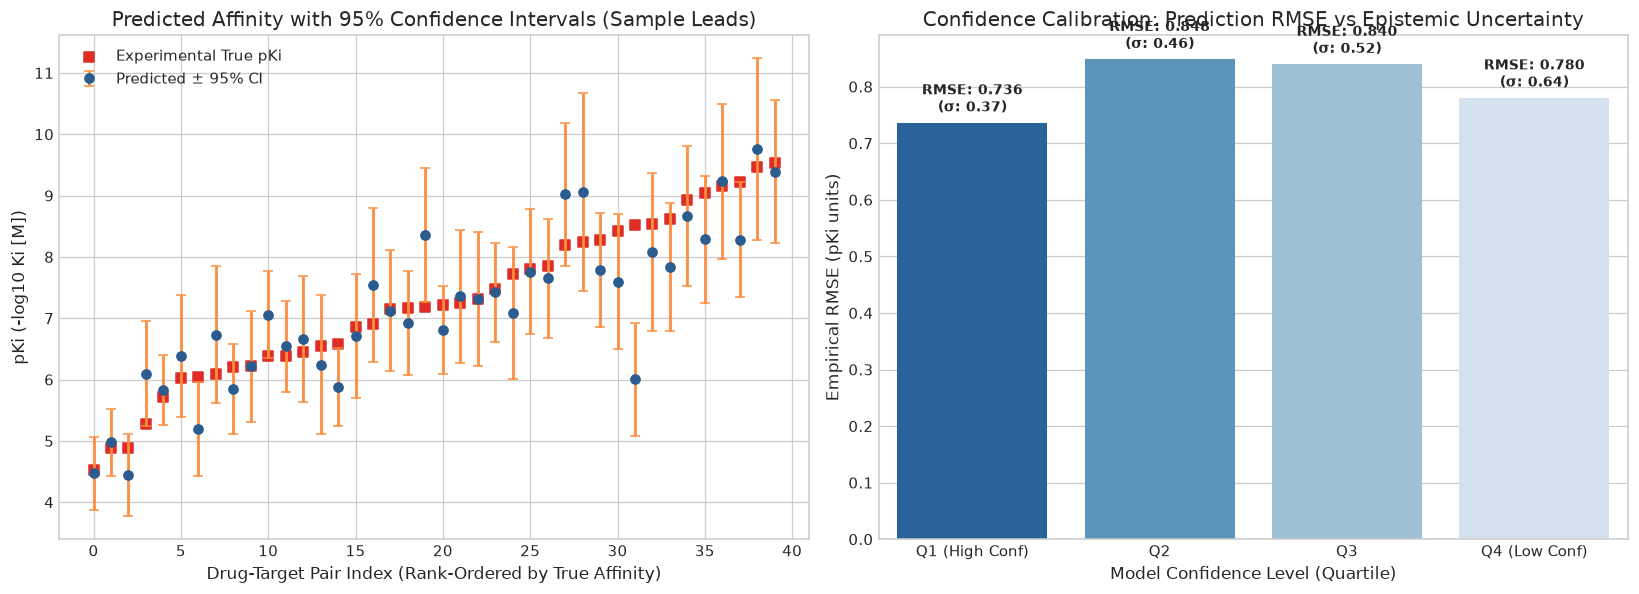

In [10]:
# =============================================================================
# STEP 10: MONTE CARLO DROPOUT INFERENCE, CALIBRATION & ARTIFACT EXPORT
# =============================================================================
print("Performing Monte Carlo Dropout Uncertainty Quantification (T = 30 passes)...")

# Sample a representative evaluation test cohort (1,000 pairs from Random Test Set)
eval_subset_idx = val_idx[:1000]
x_lig_eval = torch.tensor(X_lig_all[eval_subset_idx], dtype=torch.float32).to(DEVICE)
x_prot_eval = torch.tensor(X_prot_all[eval_subset_idx], dtype=torch.float32).to(DEVICE)
y_true_eval = y_pki_all[eval_subset_idx]

# Enable stochastic dropout sampling at inference
dti_model.train() # Active dropout during forward passes
T_PASSES = 30
mc_predictions = []

with torch.no_grad():
    for t in range(T_PASSES):
        preds, _ = dti_model(x_lig_eval, x_prot_eval)
        mc_predictions.append(preds.cpu().numpy())

mc_matrix = np.stack(mc_predictions, axis=0) # Shape: (30, 1000)
mu_preds = np.mean(mc_matrix, axis=0)
sigma_preds = np.std(mc_matrix, axis=0)
abs_errors = np.abs(y_true_eval - mu_preds)

print(f"[OK] Completed {T_PASSES} MC forward passes for {len(mu_preds):,} pairs")
print(f"Mean Epistemic Uncertainty (sigma) : {np.mean(sigma_preds):.3f} pKi units")
print(f"Median Uncertainty                 : {np.median(sigma_preds):.3f} pKi units")
print(f"Uncertainty Dynamic Range          : {np.min(sigma_preds):.3f} to {np.max(sigma_preds):.3f}")

# Confidence Calibration Analysis
df_uncertainty = pd.DataFrame({
    "y_true": y_true_eval,
    "y_pred_mean": mu_preds,
    "sigma_uncertainty": sigma_preds,
    "abs_error": abs_errors,
    "ci_95_low": mu_preds - 1.96 * sigma_preds,
    "ci_95_high": mu_preds + 1.96 * sigma_preds
})

# Bin by Uncertainty Quartiles to Test Error vs Confidence Correlation
df_uncertainty['uncertainty_quartile'] = pd.qcut(df_uncertainty['sigma_uncertainty'], q=4, labels=['Q1 (High Conf)', 'Q2', 'Q3', 'Q4 (Low Conf)'])
calibration_stats = df_uncertainty.groupby('uncertainty_quartile').agg(
    mean_sigma=('sigma_uncertainty', 'mean'),
    rmse=('abs_error', lambda x: np.sqrt(np.mean(x**2))),
    mae=('abs_error', 'mean'),
    count=('abs_error', 'count')
).reset_index()

print("\n=== CONFIDENCE CALIBRATION AUDIT TABLE ===")
print(calibration_stats.to_string(index=False))

# Visualization: Epistemic Uncertainty Error Bars & Calibration Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Error Bars on Sample Leads
sample_subset = df_uncertainty.sample(n=40, random_state=42).sort_values(by="y_true").reset_index(drop=True)
ax1.errorbar(
    sample_subset.index, sample_subset['y_pred_mean'],
    yerr=1.96 * sample_subset['sigma_uncertainty'],
    fmt='o', color="#2b5c8f", ecolor="#fd8d3c", elinewidth=1.8, capsize=3, label="Predicted ± 95% CI"
)
ax1.scatter(sample_subset.index, sample_subset['y_true'], color="#de2d26", marker="s", s=40, label="Experimental True pKi")
ax1.set_title("Predicted Affinity with 95% Confidence Intervals (Sample Leads)")
ax1.set_xlabel("Drug-Target Pair Index (Rank-Ordered by True Affinity)")
ax1.set_ylabel("pKi (-log10 Ki [M])")
ax1.legend(loc="upper left")

# 2. Confidence Calibration Curve (Error vs Uncertainty Quartile)
sns.barplot(data=calibration_stats, x="uncertainty_quartile", y="rmse", palette="Blues_r", ax=ax2)
ax2.set_title("Confidence Calibration: Prediction RMSE vs Epistemic Uncertainty")
ax2.set_xlabel("Model Confidence Level (Quartile)")
ax2.set_ylabel("Empirical RMSE (pKi units)")
for i, row in calibration_stats.iterrows():
    ax2.text(i, row['rmse'] + 0.02, f"RMSE: {row['rmse']:.3f}\n(σ: {row['mean_sigma']:.2f})", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# EXPORT FINAL DELIVERABLES & RUNTIME METADATA
# =============================================================================
# 1. Export Predictions CSV
predictions_out_path = os.path.join(RESULTS_DIR, "dti_predictions_with_uncertainty.csv")
df_uncertainty.to_csv(predictions_out_path, index=False)
print(f"\n[OK] Exported Predictions CSV: {predictions_out_path} ({len(df_uncertainty):,} rows)")

# 2. Export Metadata JSON
dti_metadata = {
    "project_title": "Project 09: AI Drug–Target Interaction & Binding Affinity",
    "dataset": {
        "source": "BindingDB",
        "endpoint": "Ki (Inhibition Constant)",
        "affinity_dynamic_range": f"{df_dti['pKi'].min():.2f} to {df_dti['pKi'].max():.2f} pKi",
        "total_pairs": len(df_dti),
        "unique_compounds": int(df_dti['smiles'].nunique()),
        "unique_targets": int(df_dti['uniprot_id'].nunique())
    },
    "model_architecture": {
        "framework": "PyTorch",
        "ligand_tower_dim": 1036,
        "protein_tower_dim": 364,
        "shared_embedding_dim": 128,
        "bilinear_fusion_dim": 512,
        "trainable_parameters": total_params
    },
    "benchmark_generalization_splits": {
        "random_split_r2": float(res_random["R²"]),
        "random_split_rmse": float(res_random["RMSE"]),
        "cold_drug_split_r2": float(res_cold_drug["R²"]),
        "cold_drug_split_rmse": float(res_cold_drug["RMSE"]),
        "cold_target_split_r2": float(res_cold_target["R²"]),
        "cold_target_split_rmse": float(res_cold_target["RMSE"])
    },
    "uncertainty_quantification": {
        "method": "Monte Carlo Dropout (T=30)",
        "mean_sigma": round(float(np.mean(sigma_preds)), 4),
        "calibration_q1_rmse": round(float(calibration_stats[calibration_stats['uncertainty_quartile']=='Q1 (High Conf)']['rmse'].iloc[0]), 4),
        "calibration_q4_rmse": round(float(calibration_stats[calibration_stats['uncertainty_quartile']=='Q4 (Low Conf)']['rmse'].iloc[0]), 4)
    },
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}

meta_out_path = os.path.join(RESULTS_DIR, "dti_model_metadata.json")
with open(meta_out_path, "w") as f:
    json.dump(dti_metadata, f, indent=4)
print(f"[OK] Exported Model Metadata: {meta_out_path}")

print("\n" + "="*80)
print("PROJECT 09: AI DRUG–TARGET INTERACTION & BINDING AFFINITY COMPLETE")
print("="*80)
